In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.shape
df.to_csv('../data/titanic.csv', index=False)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
df.nunique()

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [6]:
[(c, df[c].unique()[:6]) for c in df.columns if df[c].nunique() < 10]

[('survived', array([0, 1])),
 ('pclass', array([3, 1, 2])),
 ('sex',
  <StringArray>
  ['male', 'female']
  Length: 2, dtype: str),
 ('sibsp', array([1, 0, 3, 4, 2, 5])),
 ('parch', array([0, 1, 2, 5, 3, 4])),
 ('embarked',
  <StringArray>
  ['S', 'C', 'Q', nan]
  Length: 4, dtype: str),
 ('class',
  ['Third', 'First', 'Second']
  Categories (3, str): ['First', 'Second', 'Third']),
 ('who',
  <StringArray>
  ['man', 'woman', 'child']
  Length: 3, dtype: str),
 ('adult_male', array([ True, False])),
 ('deck',
  [NaN, 'C', 'E', 'G', 'D', 'A']
  Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']),
 ('embark_town',
  <StringArray>
  ['Southampton', 'Cherbourg', 'Queenstown', nan]
  Length: 4, dtype: str),
 ('alive',
  <StringArray>
  ['no', 'yes']
  Length: 2, dtype: str),
 ('alone', array([False,  True]))]

In [7]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [8]:
df[['survived', 'alive']].head(10)

,survived,alive
0,0,no
1,1,yes
2,1,yes
3,1,yes
4,0,no
5,0,no
6,0,no
7,0,no
8,1,yes
9,1,yes


In [9]:
pd.crosstab(df['survived'], df['alive'])

alive,no,yes
survived,,
0,549,0
1,0,342


В выборке есть колонки которые повоторяют информацию, в целом если это не целевые переменные то не особо страшно, но если да то вся модель ломается, пример survived и alive, если бы я обучал модель предсказывать выживет ли человек на 2 титанике то она бы сначала показывала бы 100% правильный ответ, ведь модель бы нашла закономерность alive - no => survived - 0 и наоборот, поэтому на нормальном испытании где заранее не известно выжил ли человек или нет она бы посыпалась. Важно удалять данные которые дублируют ответ.

In [10]:
df.groupby('embarked')['survived'].mean()

embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64

По данным видно что город откдуа ты отплыл имел вес в вероятности выживания, поэтому думаю надо заполнить 2 пропуска в таблице самыми вероятными значениями и оставить её (по emark_town тоже самое)

In [11]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

Теперь надо решить по столбцу deck

In [12]:
df.groupby(df['deck'].isnull())['survived'].agg(['count', 'mean'])

,count,mean
deck,,
False,203,0.669951
True,688,0.299419


По данным вижидно что наличие данных в столбце deck влияло на вероятность выживания

In [13]:
df.groupby('deck')['survived'].mean()

deck
A    0.466667
B    0.744681
C    0.593220
D    0.757576
E    0.750000
F    0.615385
G    0.500000
Name: survived, dtype: float64

In [14]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Думаю стоит оставить этот столбец а пропуски заменить на палуб неизвестна так как это может быть полезно для модели судя по результатам выше

In [15]:
df['deck'] = df['deck'].cat.add_categories('Unknown_deck')
df['deck'] = df['deck'].fillna('Unknown_deck')

Теперь age

In [16]:
df.groupby(df['age'].isnull())['survived'].mean()

age
False    0.406162
True     0.293785
Name: survived, dtype: float64

<Axes: xlabel='age', ylabel='survived'>

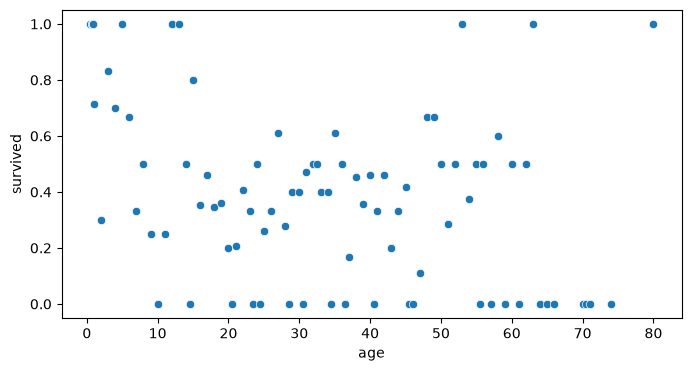

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=df.groupby('age')['survived'].mean().reset_index(), x='age', y='survived')

Посмотрев на график я увидел что у людей примерно до 16 лет болше шансов выжить чем у людей чей возраст после 16 лет, но в столбце есть 177 пропусков думаю стоит сделать флаг неизвестного возраста и оставить не пропущенные значения, но вставлять строку в столбец с числами нельзя поэтому сначала создам столбец с фалагами возраст известен либо нет

In [18]:
df['age_missing'] = (df['age'].isnull()).astype('int8')

теперь чтобы не было пропусков в age надо заполнить nan какими то цифрами но при этом чтобы они не особо ломали статистику

In [19]:
df['age'].isnull().groupby(df['pclass']).mean()

pclass
1    0.138889
2    0.059783
3    0.276986
Name: age, dtype: float64

In [20]:
df.groupby('pclass')['age'].mean()

pclass
1    38.233441
2    29.877630
3    25.140620
Name: age, dtype: float64

In [21]:
df.groupby('pclass')['age'].median()

pclass
1    37.0
2    29.0
3    24.0
Name: age, dtype: float64

Введу просто меддианный возраст

In [22]:
df['age'] = df.groupby('pclass')['age'].transform(lambda s: s.fillna(s.median()))

Также не забываю удалить дубликат alive

In [23]:
df = df.drop(columns=['alive'])

In [24]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alone          0
age_missing    0
dtype: int64

In [25]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alone              bool
age_missing        int8
dtype: object

Отвечаю на впоросы:
1. Различалась ли выживаемость мужчин и женщин?

Text(0.5, 1.0, 'Выживаемость по полу')

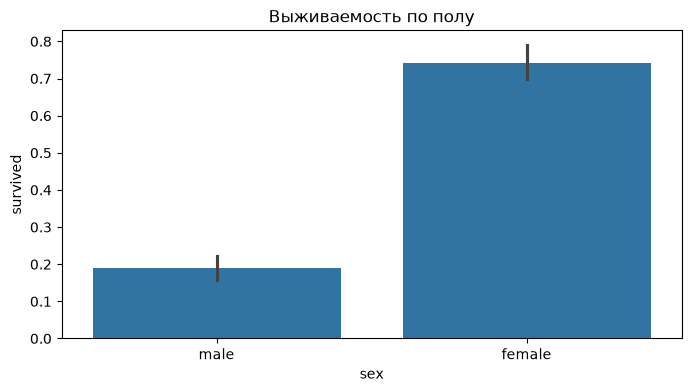

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='sex', y='survived')
ax.set_title('Выживаемость по полу')

In [27]:
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Выживаемость женщин - 74%, когда у мужчин всего - 18% или 19% если округлять, получилось что выживаемость женщин в 4.1 раз выше чем у мужчин, так же это может быть связано с классом что я проверю ниже

In [28]:
(df['sex'] == 'female').groupby(df['pclass']).mean()

pclass
1    0.435185
2    0.413043
3    0.293279
Name: sex, dtype: float64

видно что в 1 и 2 классе женщин чуть меньше мужчин а в третьем классе их уже чуть меньше 1/3, а как мы узнали выше у 3 класса самая плохая выживаемость, проверю еще сначала еще соотношение полов среди тех у кого не было класса

In [29]:
(df['sex'] == 'female').groupby(df['deck'].isnull()).agg(['count', 'mean'])

,count,mean
deck,,
False,891,0.352413


Вывод: женщин по соотношению оказалось больше в 1 и 2 классе, а в 3 и без класса их там примерно 1/3, что и повлияло на их высокую выживаемость

2. Как выживаемость зависит от класса каюты?
На этот вопрос приводились данные выш, вот результаты: 1 класс - 62%, 2 класс - 47%, 3 класс - 24%

Text(0.5, 1.0, 'Выживаемость по классу')

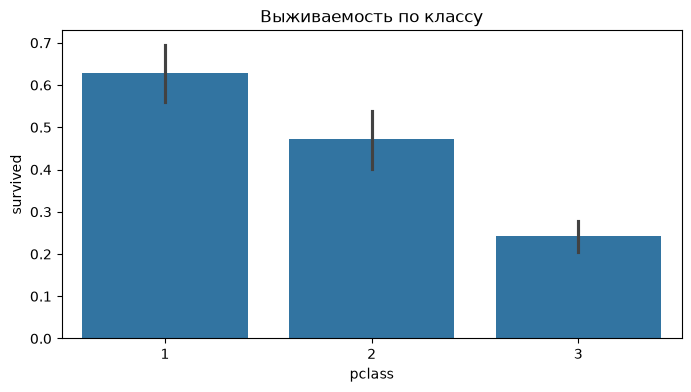

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='pclass', y='survived')
ax.set_title('Выживаемость по классу')

Вывод: Номер класса влияет на выживаемость, чем выше класс обслуживания (меньше номер), тем выше шанс на выживание

3. Чья выживаемость выше судя и по классу и по полу одновременно?

Text(0.5, 1.0, 'Выживаемость по полу и классу')

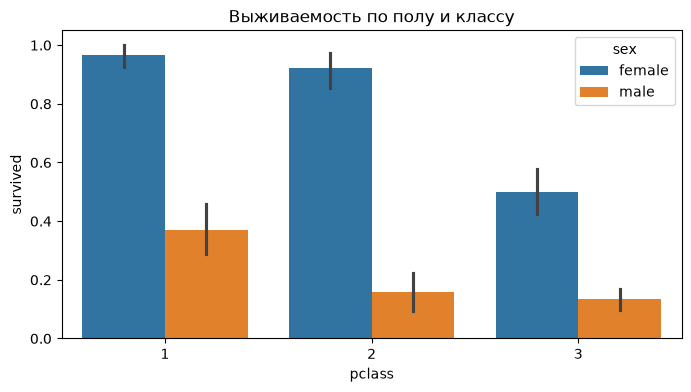

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='pclass', y='survived', hue='sex')
ax.set_title('Выживаемость по полу и классу')

In [32]:
df[df['sex'] == 'female'].groupby('pclass')['survived'].mean()

pclass
1    0.968085
2    0.921053
3    0.500000
Name: survived, dtype: float64

In [33]:
df[df['sex'] == 'male'].groupby('pclass')['survived'].mean()

pclass
1    0.368852
2    0.157407
3    0.135447
Name: survived, dtype: float64

Вывод: У женщины 1 и 2 классе шансы выжить близки к 100% (96% и 92%), когда у мужчин даже не перешагнули за 50 (36%, 15%), в 3 классе шансы выжить у женщин резко падают до 50% и всё равно это в более чем 3 раза больше чем шанс выжить у мужчины из 3 класса (13%), исходя из данных можно сделать вывод, что высокая выживаемость в 1 и 2 классе обусловлена именно высокой выживаемостью женщин а не мужчин.

4. Как влияет возраст на выживаемость?

Text(0.5, 1.0, 'Доля выживших и погибших по возрасту')

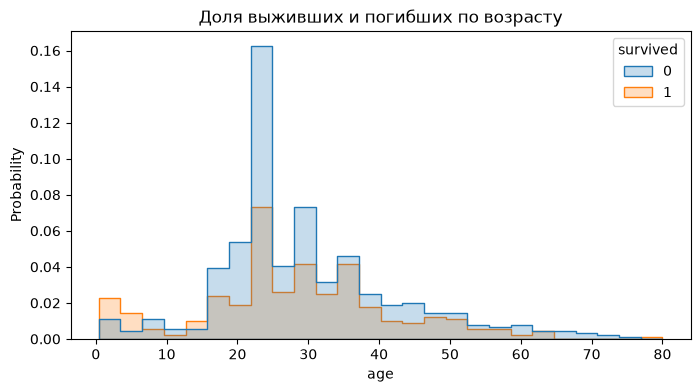

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='survived', stat='probability', element='step')
ax.set_title('Доля выживших и погибших по возрасту')

In [35]:
df[(df['age'] <= 8) & (df['age_missing'] == 0)]['survived'].mean()

np.float64(0.6666666666666666)

In [36]:
df[(df['age'] > 8) & (df['age'] <= 16) & (df['age_missing'] == 0)]['survived'].mean()

np.float64(0.41304347826086957)

In [37]:
df[(df['age'] > 16) & (df['age'] <= 32) & (df['age_missing'] == 0)]['survived'].mean()

np.float64(0.3699421965317919)

In [38]:
df[(df['age'] > 32) & (df['age'] <= 64) & (df['age_missing'] == 0)]['survived'].mean()

np.float64(0.41245136186770426)

In [39]:
df[(df['age'] > 64) & (df['age_missing'] == 0)]['survived'].mean()

np.float64(0.09090909090909091)

Вывод: Самый высокий шанс выжить это у людей младше 8 лет (66%), у людей от 9 до 16 - 41%, от 17 до 32 - 36%, от 33 до 64 - 41% и самый маленький шанс выжить у людей старше 64 - 9% (Правда это шанс по 11 людям, так же я посчитал что доверительный интервал в 3 раза больше стандартной ошибки) 

5. Влияет ли цена билета на выживаемость?

Text(0.5, 1.0, 'Разница билетов у выживших и нет')

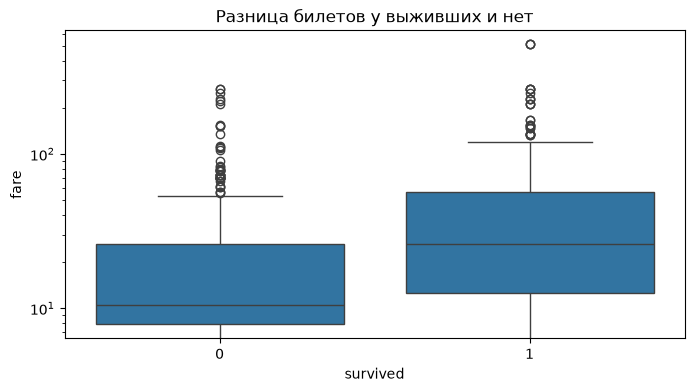

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='survived', y='fare')
ax.set_yscale('log')
ax.set_title('Разница билетов у выживших и нет')

Text(0.5, 1.0, 'Выживаемость по стоимости билетов')

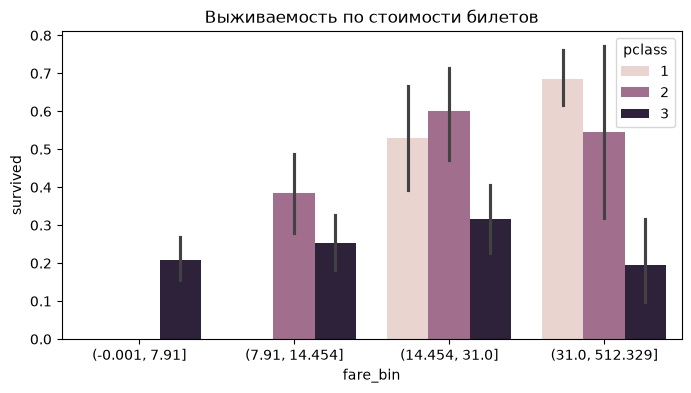

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
df['fare_bin'] = pd.qcut(df['fare'], q=4)
sns.barplot(data=df, x='fare_bin', y='survived', hue='pclass', ax=ax)
ax.set_title('Выживаемость по стоимости билетов')

In [42]:
df.groupby('pclass')['fare'].median()

pclass
1    60.2875
2    14.2500
3     8.0500
Name: fare, dtype: float64

In [43]:
df.groupby(['pclass', 'survived'])['fare'].median()

pclass  survived
1       0           44.7500
        1           77.9583
2       0           13.0000
        1           21.0000
3       0            8.0500
        1            8.5167
Name: fare, dtype: float64

Вывод: Цена билета влияет на шанс выжить, чем больше цена тем выше шнас, но есть одна оговорка, у цены билета 1 и 2 класса медианная цена выживших была почти в 2 раза больше медианной цены билета погбиших, в то время как в 3 классе медианные ценны почти не отличаются 8.050 и 8.516, еще можно добавить что дорогой билет означал практически 100 процентную выживаемость для женщины со 2 класса и примерно 36 проценьную для мужчины начиная с 1 класса

6. Влияло ли то что ты путешествуешь один или с семьёй?

Text(0.5, 1.0, 'Выживаемость по одиночеству')

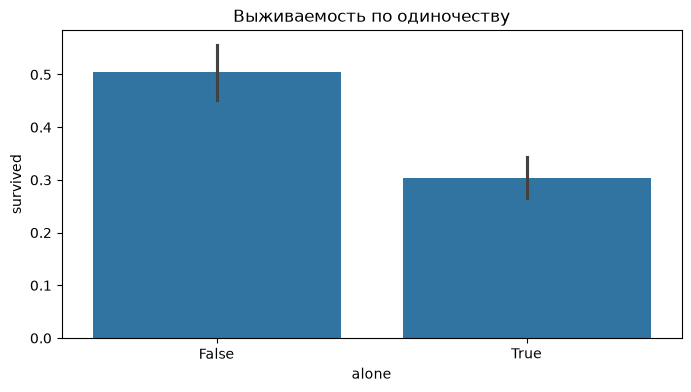

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='alone', y='survived')
ax.set_title('Выживаемость по одиночеству')

In [45]:
df.groupby('alone')['survived'].mean()

alone
False    0.505650
True     0.303538
Name: survived, dtype: float64

In [46]:
df.groupby('alone')['sex'].value_counts(normalize=True)

alone  sex   
False  female    0.531073
       male      0.468927
True   male      0.765363
       female    0.234637
Name: proportion, dtype: float64

Вывод: те кто путешествовали не в одиночку чаще выживали чем те кто путешествовали в одоного, также хочу подчеркнуть что среди одиноких76% это мужчины у которых шанс на выживание по полу 18%

7. Влиял ли порт посадки на шансы выжить?

Text(0.5, 1.0, 'Выживаемость по порту посадки и классу')

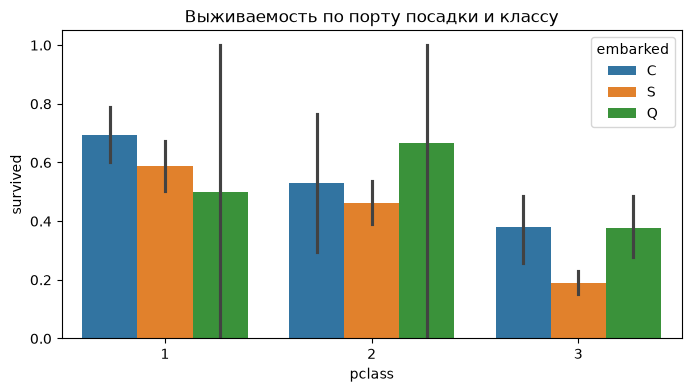

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='pclass', y='survived', hue='embarked')
ax.set_title('Выживаемость по порту посадки и классу')

In [48]:
df[df['embarked'] == 'C'].groupby('pclass')['survived'].mean()

pclass
1    0.694118
2    0.529412
3    0.378788
Name: survived, dtype: float64

In [49]:
df[df['embarked'] == 'S'].groupby('pclass')['survived'].mean()

pclass
1    0.589147
2    0.463415
3    0.189802
Name: survived, dtype: float64

In [50]:
df[df['embarked'] == 'Q'].groupby('pclass')['survived'].mean()

pclass
1    0.500000
2    0.666667
3    0.375000
Name: survived, dtype: float64

In [51]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Вывод: Можно увидеть что для людей с портом посадки S из 3 класса шансы выжить практически в 2 раза ниже чем у других людей из 3 класса

Кореляционная матрица:

<Axes: >

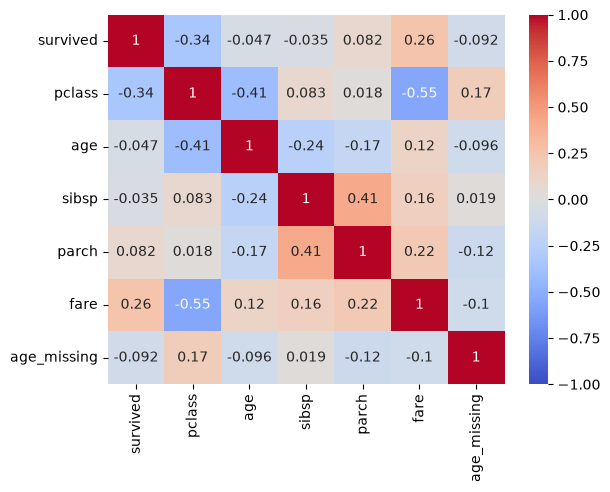

In [52]:
num = df.select_dtypes(include='number')
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

На матрице кореляции есть колонки survived, pclass, age, sibsp, parch, fare, age_missing, pclass это просто числа 1, 2, 3, но чем больше число тем хуже поэтому и кореляция с ними отрицательная например чем больше ты платишь за билет ем меньше номер класса, то есть тем выше класс обслуживания, пару fare, pclass нельзя считать тавтологией ведь есть люди из 2 которые заплатили за билеты больше чем люди из 1 класса а значит не является дублированием уже существующей информации.

In [53]:
df.groupby('pclass')['fare'].agg(['min', 'max'])

,min,max
pclass,,
1,0.0,512.3292
2,0.0,73.5000
3,0.0,69.5500


Главный вывод:
1. На матрице кореляции видно fare, pclass -0.55, действительно чем меньше твой класс тем больше стоит твой билет и это самая сильная кореляция, а pclass, survived -0.34
2. Шанс на выживание больше всего был у женщин из 1 - 2 класса
3. От класса сильно зависила выживаемость, чем выше класс обслуживания (меньше номер), тем выше шанс, вот шансы - 63/47/24
4. У мужчин шанс на выживание был силльно ниже чем у женщин даже в первом классе 96 и 36 а шанс выживания женщины из 1 класса больше в 7 раз чем у мужчины из 3
5. У детей тоже был шанс выжить больше, дети до 8 лет выживают с шансо в 66% когда как взрослые примерно с шансом 38%
6. Путешествуя вместе шансов выжить больше чем в одиночку 51% против 30%, также хочу подчеркнуть что среди одиноких 76% это мужчины у которых шанс на выживание по полу 18%
7. Почему, если шанс у ребенка выжить больше, нет кореляции у age, survived в таблице? Потому что зависимость не монотонная, шанс выжить несколько раз растет и падает, видно это под таблицей "Доля выживших и погибших по возрасту"
8. Медианная цена билета у выживших больше чем у погибших почти в два раза у людей из 1 и 2 класса, когда у 3 класса медианные цены на билет не отличаются, хотя это болььше половины выборки
9. Люди с портом отправки S из 3 класса имели в два раза меньше шанса выжить чем люди с другими портами отправки из 3 класса

Ограничения:
1. 891 запись из примерно 2200 человек на борту, только пассажиры, без экипажа;
2. возраст восстановлен у 177 человек (20%) медианой по классу;
3. все найденные связи — корреляционные; данные не позволяют утверждать причину;
4. пол, класс, цена и порт связаны между собой, поэтому эффекты нельзя складывать.